In [1]:
from pathlib import Path
from typing import List, Optional, Tuple
import tifffile
from skimage.morphology import white_tophat
import napari
import matplotlib.pyplot as plt
import numpy as np
from skimage.exposure import rescale_intensity

import pandas as pd
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.filters import (
    gaussian,
    threshold_li,
    threshold_mean,
    threshold_triangle,
    try_all_threshold,
    threshold_otsu,
    threshold_minimum,
    threshold_local,
    threshold_isodata
    
)
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import (
    closing,
    disk,
    erosion,
    h_maxima,
    remove_small_holes,
    remove_small_objects
)
from skimage.segmentation import expand_labels, watershed
from skimage.filters import threshold_yen
from skimage.filters import median as median_filter
from skimage.morphology import square


In [2]:
folder = Path(r"Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix")
tif_files = sorted(folder.glob("**/*.tif"))

In [3]:
_CH_BF = 0
_CH_BCELL_RAW = 1
_CH_VASC_RAW = 2
_CH_CART_RAW = 3
_CH_CHIP = 4
_CH_TUMOUR = 5
_CH_LEFT = 6
_CH_RIGHT = 7
_CH_VASC_MASK = 8
_CH_BCELL_MASK = 9
_CH_CART_MASK = 10

In [ ]:
# n_channels = test.shape[0]
# fig, ax = plt.subplots(ncols = n_channels, figsize=(2*n_channels, 3))
# for i in range(n_channels):
#     ax[i].imshow(test[i,:,:], cmap="gray")
#     ax[i].axis("off")

Processing Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\CART_FL7_16.07.2026_ARi_device1_img0.tif
0 100


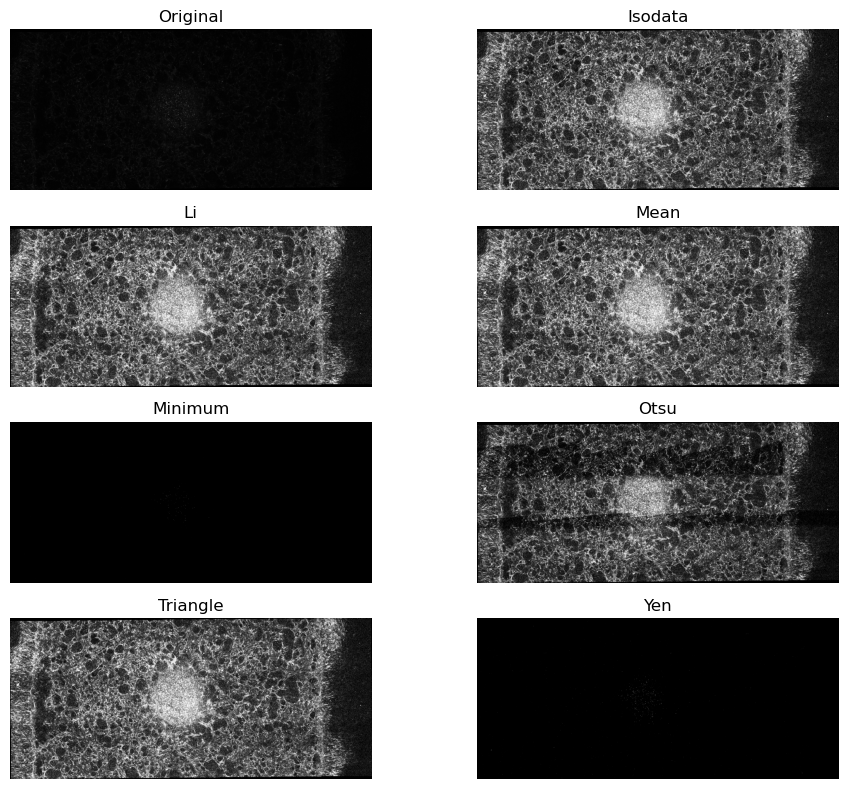

Processing Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\CART_FL7_16.07.2026_ARi_device2_img2.tif
0 100


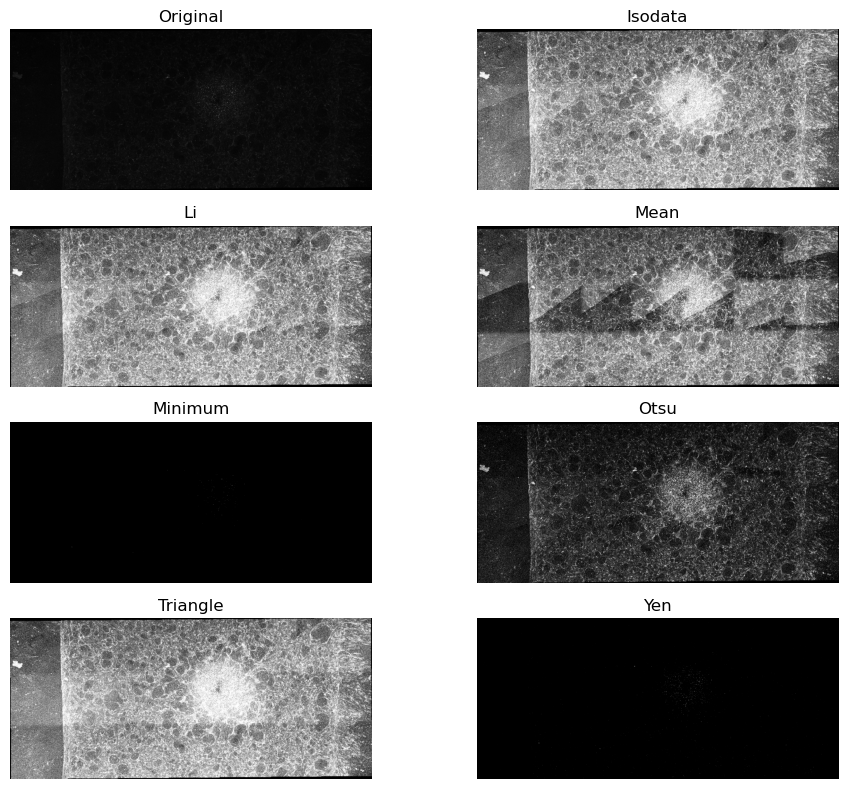

Processing Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\CART_FL7_16.07.2026_UTD_device1_img1.tif
0 100


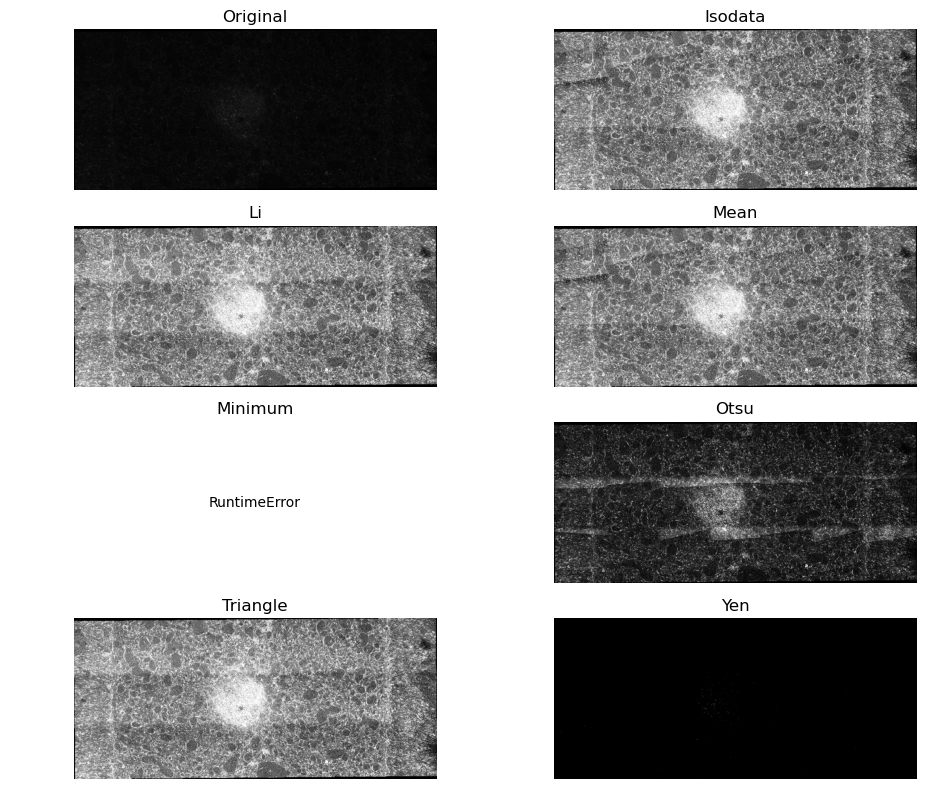

Processing Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\CART_FL7_16.07.2026_UTD_device2_img3.tif
0 100


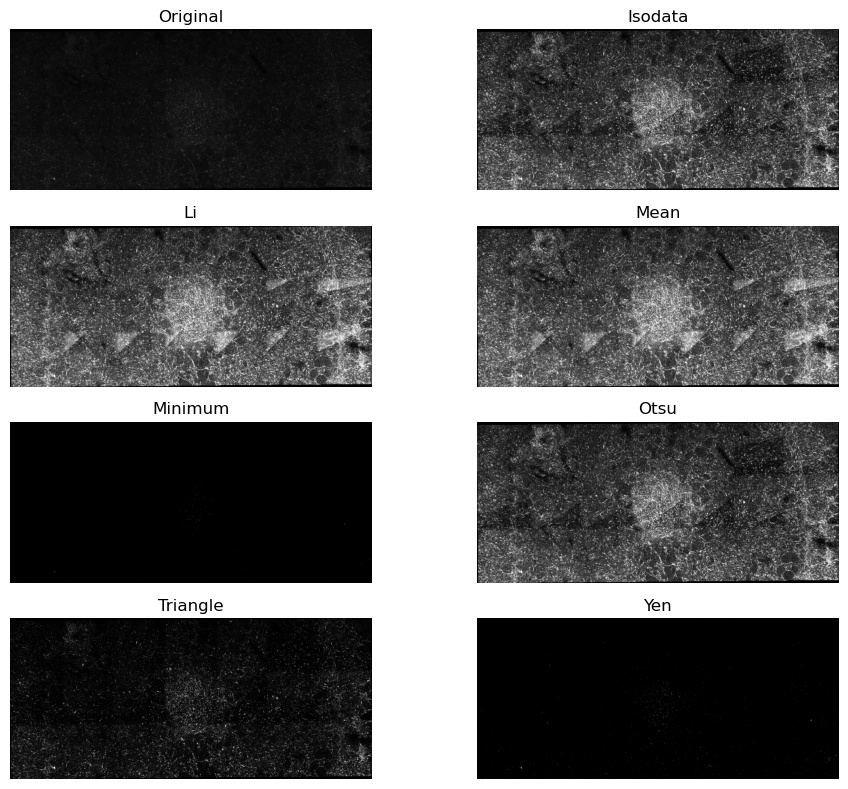

Processing Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\CART_FL7_16.07.2026_UTD_device3_img5.tif
0 100


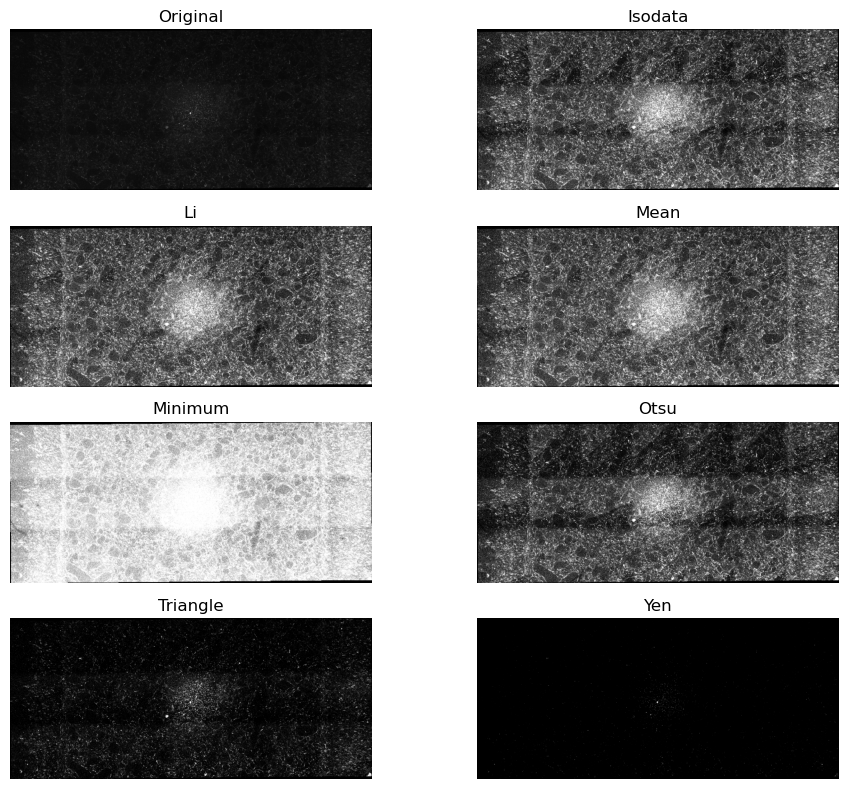

In [ ]:
for tif_file in tif_files:
    print(f"Processing {tif_file}")
    image = tifffile.imread(tif_file)

    original_b = image[_CH_BCELL_RAW, :, :]
    rescaled_b = np.clip(original_b, 0, 100)
    print(np.min(rescaled_b), np.max(rescaled_b))

    original_b_seg = image[_CH_BCELL_MASK, :, :]
    fig, ax = try_all_threshold(rescaled_b, figsize=(10, 8), verbose=False)
    plt.show()
    

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


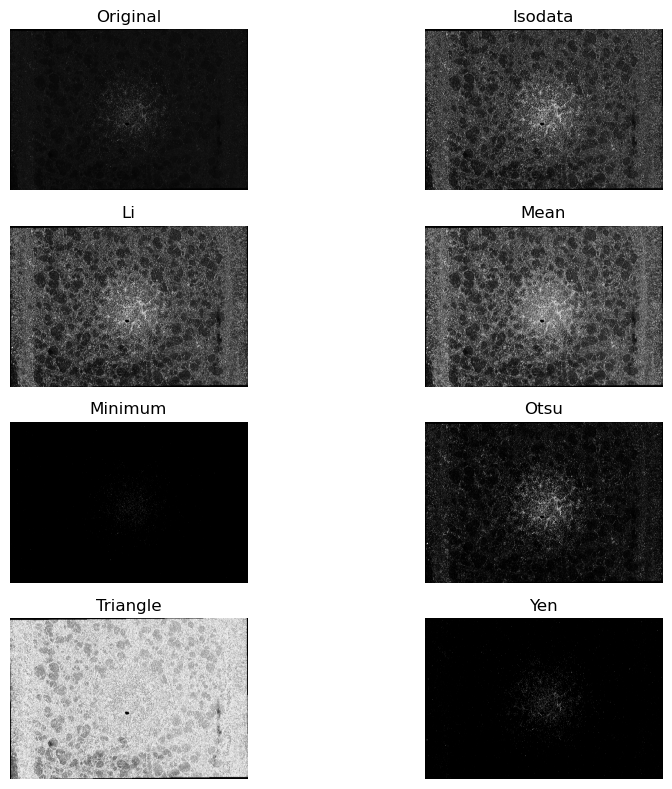

In [ ]:
# raw_bcells = test[_CH_BCELL_RAW,:,:]
# bg_removed = white_tophat(raw_bcells, footprint=disk(5))
# try_all_threshold(bg_removed, figsize=(10, 8))
# plt.show()
# # bcell_seg_bg = bg_removed > threshold_triangle(bg_removed)
# # bcell_seg_bg = remove_small_objects(bcell_seg_bg, min_size=2)


# # bg_estimate = gaussian(raw_bcells.astype(float), sigma=2)
# # bg_removed_gauss = np.clip(raw_bcells.astype(float) - bg_estimate, 0, None).astype(raw_bcells.dtype)
# # try_all_threshold(bg_removed_gauss, figsize=(10, 8))
# # plt.show()





In [38]:
viewer = napari.Viewer()
viewer.add_image(raw_bcells, name="raw bcells")
viewer.add_image(bg_removed, name="bg removed")
viewer.add_labels(remove_small_objects(bg_removed > threshold_yen(bg_removed), min_size=2), name="yen + bg")
viewer.add_labels(remove_small_objects(raw_bcells > threshold_yen(raw_bcells), min_size=2), name="yen")

# viewer.add_labels(remove_small_objects(bg_removed_gauss > threshold_otsu(bg_removed_gauss), min_size=2), name="gauss + otsu")
# viewer.add_labels(bg_removed > threshold_yen(bg_removed), name="yen")

block_size = 5 # adjust: ~2–3x the diameter of a typical cell in pixels

# viewer.add_labels(
# remove_small_objects(bg_removed > threshold_local(bg_removed, block_size=block_size), min_size=2),
# name=f"tophat – local (b={block_size})",
# )


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_28892\1589640907.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  viewer.add_labels(remove_small_objects(bg_removed > threshold_yen(bg_removed), min_size=2), name="yen + bg")
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_28892\1589640907.py:5: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parame

In [4]:
def segment_bcells(image, max_clipping_value: Optional[int] = None, save_path: Optional[Path] = None):
    raw_bcells = image[_CH_BCELL_RAW,:,:]
    if max_clipping_value is not None:
        raw_bcells = np.clip(raw_bcells, a_min=0, a_max=max_clipping_value)
    bg_removed = white_tophat(raw_bcells, footprint=disk(5))
    # bcell_seg_bg = bg_removed > threshold_triangle(bg_removed)
    # bcell_seg_bg = remove_small_objects(bcell_seg_bg, min_size=2)
    bcell_seg_bg = remove_small_objects(bg_removed > threshold_triangle(bg_removed), min_size=2)
    image[_CH_BCELL_MASK, :, :] = bcell_seg_bg
    if save_path is not None:
        tifffile.imwrite(save_path, bcell_seg_bg.astype(np.uint8))
# def segment_cart_cells(image):
#     raw_cartcells = image[_CH_CART_RAW,:,:]
#     bg_removed_CART = white_tophat(raw_cartcells, footprint=disk(5))
#     CART_seg_bg = bg_removed_CART > threshold_triangle(bg_removed_CART)
#     CART_seg_bg = remove_small_objects(CART_seg_bg, min_size=2)
#     image[_CH_CART_MASK, :, :] = CART_seg_bg
# def segment_vasculature(image):
#     raw_vasculature = image[_CH_VASC_RAW,:,:]
#     raw_vasculature.max(), raw_vasculature.min()
#     vasc_med = median_filter(raw_vasculature, footprint=square(7))
#     smooth_vasc = gaussian(vasc_med, sigma=3)
#     seg = smooth_vasc > threshold_mean(smooth_vasc)
#     image[_CH_VASC_MASK,:,:] = seg


In [ ]:
folder = Path(r"Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\in")
tif_files = sorted(folder.glob("**/*.tif"))
# output_folder = Path(r"Z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\toredo\out")
# output_folder.mkdir(parents=True, exist_ok=True)

output_root = Path(r"Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\stage3\to_fix\out_bcells")
output_folders = ["triangle_noclip", "triangle_170clip", "triangle_200clip"]


for i, max_clip in enumerate([None, 170, 200]):
    print(f"Processing with max_clip={max_clip}")
    for tif_path in tif_files:
        print(f"Processing {tif_path.stem}")
        # Read full image plus original metadata so we can write it back unchanged
        with tifffile.TiffFile(tif_path) as tf:
            image = tf.asarray()
            imagej_metadata = tf.imagej_metadata
            ome_metadata = tf.ome_metadata
            is_imagej = tf.is_imagej
            is_ome = tf.is_ome
            first_page = tf.pages[0]
            resolution = first_page.tags.get("XResolution"), first_page.tags.get("YResolution")
            resolution_unit = first_page.tags.get("ResolutionUnit")
            x_res = first_page.tags["XResolution"].value if "XResolution" in first_page.tags else None
            y_res = first_page.tags["YResolution"].value if "YResolution" in first_page.tags else None
    
        # Overwrite only the three mask channels in-place
        out_path = output_root / output_folders[i] / tif_path.name
        (output_root / output_folders[i]).mkdir(parents=True, exist_ok=True)
        segment_bcells(image, max_clipping_value=max_clip, save_path=out_path )
        # segment_cart_cells(image)
        # segment_vasculature(image)

        # out_path = output_root / output_folders[i] / tif_path.name
        # (output_root / output_folders[i]).mkdir(parents=True, exist_ok=True)

        write_kwargs = {}
        if x_res is not None and y_res is not None:
            # XResolution/YResolution are rationals (numerator, denominator)
            write_kwargs["resolution"] = (
                x_res[0] / x_res[1],
                y_res[0] / y_res[1],
            )

        if is_imagej:
            tifffile.imwrite(
                out_path,
                image,
                imagej=True,
                metadata=imagej_metadata,
                **write_kwargs,
            )
        elif is_ome:
            tifffile.imwrite(
                out_path,
                image,
                ome=True,
                description=ome_metadata,
                **write_kwargs,
            )
        else:
            tifffile.imwrite(
                out_path,
                image,
                **write_kwargs,
            )

        print(f"Saved {out_path.name}")


Processing with max_clip=None
Processing CART_FL7_16.07.2026_ARi_device1_img0


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_2000\3263646876.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bcell_seg_bg = remove_small_objects(bg_removed > threshold_triangle(bg_removed), min_size=2)


Saved CART_FL7_16.07.2026_ARi_device1_img0.tif
Processing CART_FL7_16.07.2026_ARi_device2_img2
Saved CART_FL7_16.07.2026_ARi_device2_img2.tif
Processing CART_FL7_16.07.2026_UTD_device1_img1
Saved CART_FL7_16.07.2026_UTD_device1_img1.tif
Processing CART_FL7_16.07.2026_UTD_device2_img3
Saved CART_FL7_16.07.2026_UTD_device2_img3.tif
Processing CART_FL7_16.07.2026_UTD_device3_img5
Saved CART_FL7_16.07.2026_UTD_device3_img5.tif
Processing with max_clip=170
Processing CART_FL7_16.07.2026_ARi_device1_img0
Saved CART_FL7_16.07.2026_ARi_device1_img0.tif
Processing CART_FL7_16.07.2026_ARi_device2_img2
Saved CART_FL7_16.07.2026_ARi_device2_img2.tif
Processing CART_FL7_16.07.2026_UTD_device1_img1
Saved CART_FL7_16.07.2026_UTD_device1_img1.tif
Processing CART_FL7_16.07.2026_UTD_device2_img3
Saved CART_FL7_16.07.2026_UTD_device2_img3.tif
Processing CART_FL7_16.07.2026_UTD_device3_img5
Saved CART_FL7_16.07.2026_UTD_device3_img5.tif
Processing with max_clip=200
Processing CART_FL7_16.07.2026_ARi_devic

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_19704\581291044.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  CART_seg_bg = remove_small_objects(CART_seg_bg, min_size=2)


<Labels layer 'bg_triangle' at 0x1a0d88b93d0>